# EDA

# Model Training, Testing, and Evaluation

## Import and Install Required Libraries

In [1]:
!pip install transformers tensorflow -q

In [2]:
import pandas as pd
import re
import numpy as np
import nltk
import time
import joblib
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, accuracy_score, f1_score)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. DATA PREPARATION (Shared Across All Models)

In [3]:
print("\n[1/6] Loading and Preparing Data...")

df = pd.read_csv('/kaggle/input/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset/rotten_tomatoes_critic_reviews.csv')
df = df[df['top_critic'] == True].copy()
df = df.dropna(subset=['review_content', 'review_type'])
df['sentiment_label'] = df['review_type'].map({'Fresh': 1, 'Rotten': 0})

# Custom stopwords (keep negations)
base_stopwords = set(stopwords.words('english'))
custom_stopwords = [w for w in base_stopwords if w not in ['not', 'never', 'no', 'nor', 'none', 'neither']]

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in custom_stopwords])
    return text

df['clean_review'] = df['review_content'].apply(clean_text)

# Split data (same split for all models)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['sentiment_label'],
    test_size=0.2, random_state=42, stratify=df['sentiment_label']
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Class distribution: Fresh={y_train.sum()}, Rotten={len(y_train)-y_train.sum()}")



[1/6] Loading and Preparing Data...
Training samples: 224,510
Test samples: 56,128
Class distribution: Fresh=133184, Rotten=91326


## 2. TF-IDF VECTORIZATION (For LR, NB, SVM)

In [4]:
print("\n[2/6] Creating TF-IDF Features...")

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    stop_words=custom_stopwords,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"TF-IDF features: {X_train_vec.shape[1]:,}")



[2/6] Creating TF-IDF Features...
TF-IDF features: 10,000


## 3. MODEL TRAINING & EVALUATION FUNCTION

In [5]:
def train_and_evaluate(model, name, X_train, X_test, y_train, y_test, threshold=0.5):
    """Train model and return metrics"""
    print(f"\n{'='*80}")
    print(f"🔹 Training: {name}")
    print(f"{'='*80}")
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # Get probabilities (if available)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    except:
        y_proba = None
        roc_auc = None
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_rotten = f1_score(y_test, y_pred, pos_label=0)
    f1_fresh = f1_score(y_test, y_pred, pos_label=1)
    
    results = {
        'Model': name,
        'Accuracy': acc,
        'F1 Weighted': f1_weighted,
        'F1 Rotten': f1_rotten,
        'F1 Fresh': f1_fresh,
        'ROC-AUC': roc_auc,
        'Train Time (s)': train_time,
        'Pred Time (s)': pred_time,
        'Threshold': threshold
    }
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"F1 Rotten: {f1_rotten:.4f} | F1 Fresh: {f1_fresh:.4f}")
    if roc_auc:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Training Time: {train_time:.2f}s")
    print(f"Prediction Time: {pred_time:.2f}s")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Rotten', 'Fresh']))
    
    return results, model, y_pred, y_proba


## 4. TRAIN ALL TRADITIONAL MODELS (LR, NB, SVM)

In [6]:
print("\n[3/6] Training Traditional Models...")

results_list = []
models_dict = {}

# Model 1: Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_results, lr_trained, lr_pred, lr_proba = train_and_evaluate(
    lr_model, "Logistic Regression", X_train_vec, X_test_vec, y_train, y_test, threshold=0.45
)
results_list.append(lr_results)
models_dict['LR'] = lr_trained

# Model 2: Naive Bayes
nb_model = MultinomialNB(alpha=1.0)
nb_results, nb_trained, nb_pred, nb_proba = train_and_evaluate(
    nb_model, "Naive Bayes", X_train_vec, X_test_vec, y_train, y_test
)
results_list.append(nb_results)
models_dict['NB'] = nb_trained

# Model 3: Linear SVM
svm_model = LinearSVC(max_iter=2000, class_weight='balanced')
svm_calibrated = CalibratedClassifierCV(svm_model, cv=3)
svm_results, svm_trained, svm_pred, svm_proba = train_and_evaluate(
    svm_calibrated, "Linear SVM (Calibrated)", X_train_vec, X_test_vec, y_train, y_test
)
results_list.append(svm_results)
models_dict['SVM'] = svm_trained


[3/6] Training Traditional Models...

🔹 Training: Logistic Regression
Accuracy: 0.7962
F1 Weighted: 0.7973
F1 Rotten: 0.7600 | F1 Fresh: 0.8229
ROC-AUC: 0.8787
Training Time: 0.92s
Prediction Time: 0.00s

Classification Report:
              precision    recall  f1-score   support

      Rotten       0.73      0.79      0.76     22832
       Fresh       0.85      0.80      0.82     33296

    accuracy                           0.80     56128
   macro avg       0.79      0.80      0.79     56128
weighted avg       0.80      0.80      0.80     56128


🔹 Training: Naive Bayes
Accuracy: 0.7826
F1 Weighted: 0.7767
F1 Rotten: 0.6993 | F1 Fresh: 0.8297
ROC-AUC: 0.8687
Training Time: 0.04s
Prediction Time: 0.01s

Classification Report:
              precision    recall  f1-score   support

      Rotten       0.80      0.62      0.70     22832
       Fresh       0.77      0.89      0.83     33296

    accuracy                           0.78     56128
   macro avg       0.79      0.76      0.76

## 5. DEEP LEARNING MODELS (LSTM/GRU, BERT)

In [7]:
print("\n[4/6] Training Deep Learning Models...")
print("⚠️  This may take 10-30 minutes. Ensure GPU is enabled!")

# Check for GPU
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {len(gpus) > 0}")
if gpus:
    print(f"GPU: {gpus[0]}")

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Prepare data for Deep Learning
print("\nPreparing data for Deep Learning...")
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print(f"Sequence shape: {X_train_pad.shape}")

# Model 4: LSTM
print("\n" + "="*80)
print("🔹 Training: LSTM")
print("="*80)

start_time = time.time()
lstm_model = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=3,
    validation_split=0.1,
    verbose=1
)
lstm_train_time = time.time() - start_time

start_time = time.time()
lstm_pred_proba = lstm_model.predict(X_test_pad, verbose=0).flatten()
lstm_pred = (lstm_pred_proba > 0.5).astype(int)
lstm_pred_time = time.time() - start_time

lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_f1_weighted = f1_score(y_test, lstm_pred, average='weighted')
lstm_f1_rotten = f1_score(y_test, lstm_pred, pos_label=0)
lstm_f1_fresh = f1_score(y_test, lstm_pred, pos_label=1)
lstm_roc_auc = roc_auc_score(y_test, lstm_pred_proba)

lstm_results = {
    'Model': 'LSTM',
    'Accuracy': lstm_acc,
    'F1 Weighted': lstm_f1_weighted,
    'F1 Rotten': lstm_f1_rotten,
    'F1 Fresh': lstm_f1_fresh,
    'ROC-AUC': lstm_roc_auc,
    'Train Time (s)': lstm_train_time,
    'Pred Time (s)': lstm_pred_time,
    'Threshold': 0.5
}

results_list.append(lstm_results)
models_dict['LSTM'] = lstm_model

print(f"Accuracy: {lstm_acc:.4f}")
print(f"F1 Weighted: {lstm_f1_weighted:.4f}")
print(f"F1 Rotten: {lstm_f1_rotten:.4f} | F1 Fresh: {lstm_f1_fresh:.4f}")
print(f"ROC-AUC: {lstm_roc_auc:.4f}")
print(f"Training Time: {lstm_train_time:.2f}s")
print(f"Prediction Time: {lstm_pred_time:.2f}s")

# Model 5: DistilBERT (Only if GPU available)
if len(gpus) > 0:
    print("\n" + "="*80)
    print("🔹 Training: DistilBERT")
    print("="*80)
    
    try:
        from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
        from transformers import AdamWeightDecay, TFTrainer, TFTrainingArguments
        import tensorflow as tf
        
        print("Loading DistilBERT tokenizer and model...")
        tokenizer_bert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        model_bert = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
        
        # Tokenize
        train_encodings = tokenizer_bert(X_train.tolist(), truncation=True, padding=True, max_length=128)
        test_encodings = tokenizer_bert(X_test.tolist(), truncation=True, padding=True, max_length=128)
        
        # Convert to TensorFlow dataset
        train_dataset = tf.data.Dataset.from_tensor_slices((
            dict(train_encodings),
            y_train.tolist()
        )).shuffle(1000).batch(16)
        
        test_dataset = tf.data.Dataset.from_tensor_slices((
            dict(test_encodings),
            y_test.tolist()
        )).batch(16)
        
        # Compile model
        optimizer = AdamWeightDecay(learning_rate=2e-5)
        model_bert.compile(optimizer=optimizer, loss=model_bert.compute_loss, metrics=['accuracy'])
        
        # Train
        print("Training DistilBERT (3 epochs)...")
        start_time = time.time()
        bert_history = model_bert.fit(train_dataset, epochs=3, validation_split=0.1)
        bert_train_time = time.time() - start_time
        
        # Evaluate
        start_time = time.time()
        bert_predictions = model_bert.predict(test_dataset)
        bert_pred_proba = tf.nn.softmax(bert_predictions.logits).numpy()[:, 1]
        bert_pred = (bert_pred_proba > 0.5).astype(int)
        bert_pred_time = time.time() - start_time
        
        bert_acc = accuracy_score(y_test, bert_pred)
        bert_f1_weighted = f1_score(y_test, bert_pred, average='weighted')
        bert_f1_rotten = f1_score(y_test, bert_pred, pos_label=0)
        bert_f1_fresh = f1_score(y_test, bert_pred, pos_label=1)
        bert_roc_auc = roc_auc_score(y_test, bert_pred_proba)
        
        bert_results = {
            'Model': 'DistilBERT',
            'Accuracy': bert_acc,
            'F1 Weighted': bert_f1_weighted,
            'F1 Rotten': bert_f1_rotten,
            'F1 Fresh': bert_f1_fresh,
            'ROC-AUC': bert_roc_auc,
            'Train Time (s)': bert_train_time,
            'Pred Time (s)': bert_pred_time,
            'Threshold': 0.5
        }
        
        results_list.append(bert_results)
        models_dict['BERT'] = model_bert
        
        print(f"Accuracy: {bert_acc:.4f}")
        print(f"F1 Weighted: {bert_f1_weighted:.4f}")
        print(f"F1 Rotten: {bert_f1_rotten:.4f} | F1 Fresh: {bert_f1_fresh:.4f}")
        print(f"ROC-AUC: {bert_roc_auc:.4f}")
        print(f"Training Time: {bert_train_time:.2f}s")
        print(f"Prediction Time: {bert_pred_time:.2f}s")
        
    except Exception as e:
        print(f"⚠️  DistilBERT training failed: {e}")
        print("Skipping BERT, continuing with other models...")
else:
    print("\n⚠️  No GPU detected. Skipping DistilBERT (requires GPU).")
    print("To train BERT, enable GPU in Kaggle settings (Settings > Accelerator > GPU).")


[4/6] Training Deep Learning Models...
⚠️  This may take 10-30 minutes. Ensure GPU is enabled!


2026-03-04 21:38:50.593237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772660330.765785      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772660330.812365      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772660331.231161      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772660331.231183      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772660331.231186      24 computation_placer.cc:177] computation placer alr

GPU Available: True
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Preparing data for Deep Learning...
Sequence shape: (224510, 200)

🔹 Training: LSTM


I0000 00:00:1772660360.150143      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772660360.156065      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/3
3158/3158 ━━━━━━━━━━━━━━━━━━━━ 1682s 530ms/step - accuracy: 0.7356 - loss: 0.5212 - val_accuracy: 0.8046 - val_loss: 0.4157
Epoch 2/3
3158/3158 ━━━━━━━━━━━━━━━━━━━━ 1698s 538ms/step - accuracy: 0.8243 - loss: 0.3914 - val_accuracy: 0.8147 - val_loss: 0.4013
Epoch 3/3
3158/3158 ━━━━━━━━━━━━━━━━━━━━ 1677s 531ms/step - accuracy: 0.8489 - loss: 0.3422 - val_accuracy: 0.8170 - val_loss: 0.4031
Accuracy: 0.8186
F1 Weighted: 0.8181
F1 Rotten: 0.7729 | F1 Fresh: 0.8491
ROC-AUC: 0.8959
Training Time: 5057.26s
Prediction Time: 173.74s

🔹 Training: DistilBERT
⚠️  DistilBERT training failed: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)
Skipping BERT, continuing with other models...


## 6. COMPARISON SUMMARY

In [8]:
print("\n[5/6] Generating Comparison Summary...")

results_df = pd.DataFrame(results_list)
print("\n" + "="*80)
print("📊 MODEL COMPARISON SUMMARY")
print("="*80)

# Format for display
display_df = results_df.copy()
display_df['Train Time (s)'] = display_df['Train Time (s)'].apply(lambda x: f"{x:.2f}")
display_df['Pred Time (s)'] = display_df['Pred Time (s)'].apply(lambda x: f"{x:.2f}")

print(display_df.to_string(index=False, float_format="%.4f"))

# Highlight best model for each metric
print("\n" + "="*80)
print("🏆 BEST MODEL BY METRIC")
print("="*80)

best_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
best_f1 = results_df.loc[results_df['F1 Weighted'].idxmax()]
best_roc_auc = results_df.loc[results_df['ROC-AUC'].idxmax()]
fastest_train = results_df.loc[results_df['Train Time (s)'].idxmin()]
fastest_pred = results_df.loc[results_df['Pred Time (s)'].idxmin()]

print(f"🎯 Best Accuracy: {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")
print(f"⚖️  Best F1 Weighted: {best_f1['Model']} ({best_f1['F1 Weighted']:.4f})")
print(f"📈 Best ROC-AUC: {best_roc_auc['Model']} ({best_roc_auc['ROC-AUC']:.4f})")
print(f"⚡ Fastest Training: {fastest_train['Model']} ({fastest_train['Train Time (s)']:.2f}s)")
print(f"🚀 Fastest Prediction: {fastest_pred['Model']} ({fastest_pred['Pred Time (s)']:.2f}s)")


[5/6] Generating Comparison Summary...

📊 MODEL COMPARISON SUMMARY
                  Model  Accuracy  F1 Weighted  F1 Rotten  F1 Fresh  ROC-AUC Train Time (s) Pred Time (s)  Threshold
    Logistic Regression    0.7962       0.7973     0.7600    0.8229   0.8787           0.92          0.00     0.4500
            Naive Bayes    0.7826       0.7767     0.6993    0.8297   0.8687           0.04          0.01     0.5000
Linear SVM (Calibrated)    0.7987       0.7972     0.7423    0.8348   0.8779           5.04          0.03     0.5000
                   LSTM    0.8186       0.8181     0.7729    0.8491   0.8959        5057.26        173.74     0.5000

🏆 BEST MODEL BY METRIC
🎯 Best Accuracy: LSTM (0.8186)
⚖️  Best F1 Weighted: LSTM (0.8181)
📈 Best ROC-AUC: LSTM (0.8959)
⚡ Fastest Training: Naive Bayes (0.04s)
🚀 Fastest Prediction: Logistic Regression (0.00s)


## 7. VISUALIZATION


[6/6] Creating Visualizations...


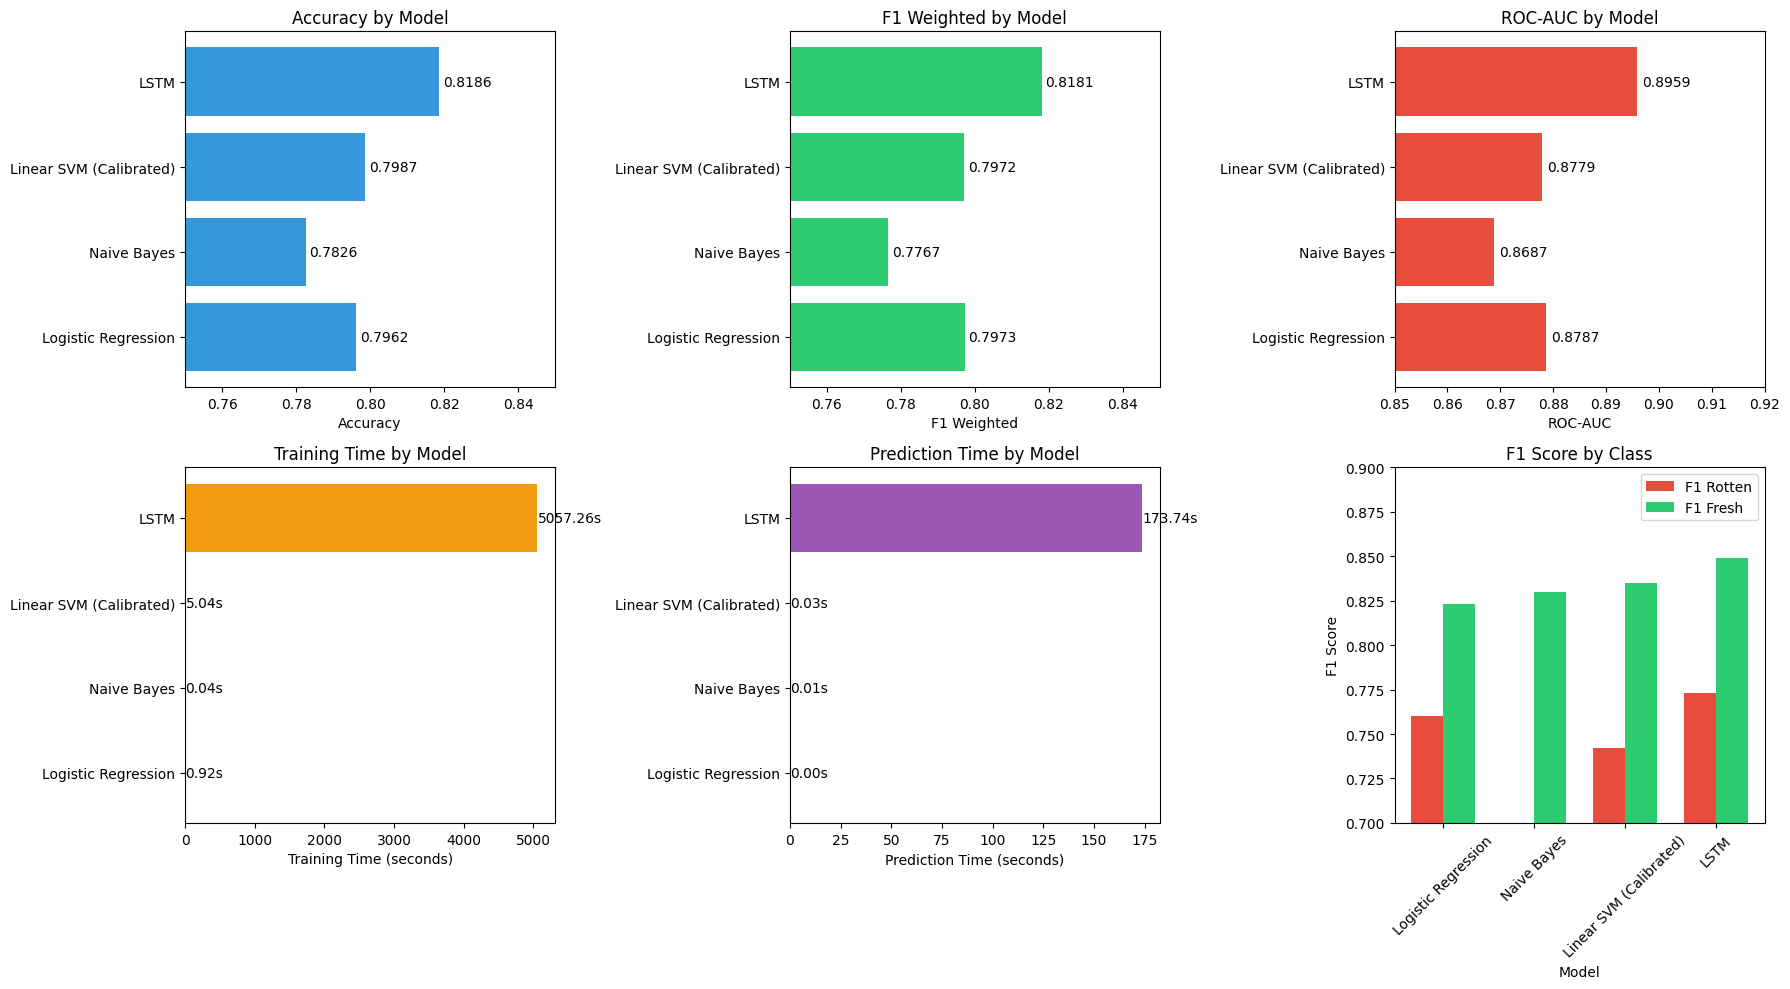

In [9]:
print("\n[6/6] Creating Visualizations...")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Accuracy Comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='#3498db')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy by Model')
axes[0, 0].set_xlim(0.75, 0.85)
for i, v in enumerate(results_df['Accuracy']):
    axes[0, 0].text(v + 0.001, i, f'{v:.4f}', va='center')

# Plot 2: F1 Weighted Comparison
axes[0, 1].barh(results_df['Model'], results_df['F1 Weighted'], color='#2ecc71')
axes[0, 1].set_xlabel('F1 Weighted')
axes[0, 1].set_title('F1 Weighted by Model')
axes[0, 1].set_xlim(0.75, 0.85)
for i, v in enumerate(results_df['F1 Weighted']):
    axes[0, 1].text(v + 0.001, i, f'{v:.4f}', va='center')

# Plot 3: ROC-AUC Comparison
axes[0, 2].barh(results_df['Model'], results_df['ROC-AUC'], color='#e74c3c')
axes[0, 2].set_xlabel('ROC-AUC')
axes[0, 2].set_title('ROC-AUC by Model')
axes[0, 2].set_xlim(0.85, 0.92)
for i, v in enumerate(results_df['ROC-AUC']):
    axes[0, 2].text(v + 0.001, i, f'{v:.4f}', va='center')

# Plot 4: Training Time
axes[1, 0].barh(results_df['Model'], results_df['Train Time (s)'].astype(float), color='#f39c12')
axes[1, 0].set_xlabel('Training Time (seconds)')
axes[1, 0].set_title('Training Time by Model')
for i, v in enumerate(results_df['Train Time (s)'].astype(float)):
    axes[1, 0].text(v + 1, i, f'{v:.2f}s', va='center')

# Plot 5: Prediction Time
axes[1, 1].barh(results_df['Model'], results_df['Pred Time (s)'].astype(float), color='#9b59b6')
axes[1, 1].set_xlabel('Prediction Time (seconds)')
axes[1, 1].set_title('Prediction Time by Model')
for i, v in enumerate(results_df['Pred Time (s)'].astype(float)):
    axes[1, 1].text(v + 0.01, i, f'{v:.2f}s', va='center')

# Plot 6: F1 by Class
x = np.arange(len(results_df))
width = 0.35
axes[1, 2].bar(x - width/2, results_df['F1 Rotten'], width, label='F1 Rotten', color='#e74c3c')
axes[1, 2].bar(x + width/2, results_df['F1 Fresh'], width, label='F1 Fresh', color='#2ecc71')
axes[1, 2].set_xlabel('Model')
axes[1, 2].set_ylabel('F1 Score')
axes[1, 2].set_title('F1 Score by Class')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(results_df['Model'], rotation=45)
axes[1, 2].legend()
axes[1, 2].set_ylim(0.70, 0.90)

plt.tight_layout()
plt.show()

## 8. SAVE ALL MODELS

In [10]:
print("\n" + "="*80)
print("💾 Saving Models...")
print("="*80)

# Save traditional models
joblib.dump({
    'LR': models_dict['LR'],
    'NB': models_dict['NB'],
    'SVM': models_dict['SVM'],
    'vectorizer': vectorizer,
    'custom_stopwords': custom_stopwords,
    'threshold': 0.45,
    'results_df': results_df
}, 'traditional_models.pkl')
print("✅ Traditional models saved to 'traditional_models.pkl'")

# Save LSTM
lstm_model.save('lstm_model.h5')
joblib.dump({'tokenizer': tokenizer, 'max_len': max_len}, 'lstm_preprocessor.pkl')
print("✅ LSTM model saved to 'lstm_model.h5'")

# Save BERT if trained
if 'BERT' in models_dict:
    models_dict['BERT'].save_pretrained('bert_model')
    tokenizer_bert.save_pretrained('bert_tokenizer')
    print("✅ DistilBERT saved to 'bert_model/'")

print("\n" + "="*80)
print("✅ MODEL COMPARISON COMPLETE!")
print("="*80)
print(f"\n📊 Results saved to: results_df")
print(f"📁 Models saved to: traditional_models.pkl, lstm_model.h5, bert_model/")
print(f"\n🏆 Recommended Model: {best_f1['Model']} (Best F1 Weighted: {best_f1['F1 Weighted']:.4f})")


💾 Saving Models...
✅ Traditional models saved to 'traditional_models.pkl'
✅ LSTM model saved to 'lstm_model.h5'

✅ MODEL COMPARISON COMPLETE!

📊 Results saved to: results_df
📁 Models saved to: traditional_models.pkl, lstm_model.h5, bert_model/

🏆 Recommended Model: LSTM (Best F1 Weighted: 0.8181)


# DistilBert Dev

In [11]:
!pip install --upgrade transformers
!pip install tensorflow
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 74.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.2.0
    Uninstalling transformers-5.2.0:
      Successfully uninstalled transformers-5.2.0


In [12]:
# Model 5: DistilBERT (PyTorch Version - FIXED)
if len(gpus) > 0:
    print("\n" + "="*80)
    print("🔹 Training: DistilBERT (PyTorch)")
    print("="*80)
    
    try:
        import torch
        from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
        from sklearn.metrics import accuracy_score, f1_score
        import numpy as np
        
        # Check if CUDA is available
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")
        
        print("Loading DistilBERT tokenizer and model...")
        tokenizer_bert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        model_bert = DistilBertForSequenceClassification.from_pretrained(
            'distilbert-base-uncased', 
            num_labels=2
        ).to(device)
        
        # Tokenize
        print("Tokenizing data...")
        train_encodings = tokenizer_bert(X_train.tolist(), truncation=True, padding=True, max_length=128)
        test_encodings = tokenizer_bert(X_test.tolist(), truncation=True, padding=True, max_length=128)
        
        # Create Dataset class
        class MovieReviewDataset(torch.utils.data.Dataset):
            def __init__(self, encodings, labels):
                self.encodings = encodings
                self.labels = labels
            
            def __getitem__(self, idx):
                item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
                item['labels'] = torch.tensor(self.labels[idx])
                return item
            
            def __len__(self):
                return len(self.labels)
        
        train_dataset = MovieReviewDataset(train_encodings, y_train.tolist())
        test_dataset = MovieReviewDataset(test_encodings, y_test.tolist())
        
        # ✅ FIXED: TrainingArguments with updated parameter names
        training_args = TrainingArguments(
            output_dir='./results',
            num_train_epochs=3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            warmup_steps=500,
            weight_decay=0.01,
            logging_dir='./logs',
            logging_steps=100,
            eval_strategy='no',          # ✅ CHANGED from 'evaluation_strategy'
            save_strategy='no',          # ✅ Keep this
            load_best_model_at_end=False,
            report_to='none',            # ✅ Disable wandb/hub reports
            fp16=True,                   # ✅ Enable mixed precision for faster training
            seed=42
        )
        
        # Compute metrics
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            predictions = np.argmax(logits, axis=-1)
            return {
                'accuracy': accuracy_score(labels, predictions),
                'f1': f1_score(labels, predictions, average='weighted')
            }
        
        # Initialize Trainer
        trainer = Trainer(
            model=model_bert,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics
        )
        
        # Train
        print("Training DistilBERT (3 epochs)...")
        start_time = time.time()
        trainer.train()
        bert_train_time = time.time() - start_time
        
        # Evaluate
        print("Evaluating...")
        start_time = time.time()
        predictions = trainer.predict(test_dataset)
        bert_pred = predictions.predictions.argmax(-1)
        bert_pred_proba = torch.softmax(torch.tensor(predictions.logits), dim=1).numpy()[:, 1]
        bert_pred_time = time.time() - start_time
        
        bert_acc = accuracy_score(y_test, bert_pred)
        bert_f1_weighted = f1_score(y_test, bert_pred, average='weighted')
        bert_f1_rotten = f1_score(y_test, bert_pred, pos_label=0)
        bert_f1_fresh = f1_score(y_test, bert_pred, pos_label=1)
        bert_roc_auc = roc_auc_score(y_test, bert_pred_proba)
        
        bert_results = {
            'Model': 'DistilBERT (PyTorch)',
            'Accuracy': bert_acc,
            'F1 Weighted': bert_f1_weighted,
            'F1 Rotten': bert_f1_rotten,
            'F1 Fresh': bert_f1_fresh,
            'ROC-AUC': bert_roc_auc,
            'Train Time (s)': bert_train_time,
            'Pred Time (s)': bert_pred_time,
            'Threshold': 0.5
        }
        
        results_list.append(bert_results)
        models_dict['BERT'] = model_bert
        
        print(f"Accuracy: {bert_acc:.4f}")
        print(f"F1 Weighted: {bert_f1_weighted:.4f}")
        print(f"F1 Rotten: {bert_f1_rotten:.4f} | F1 Fresh: {bert_f1_fresh:.4f}")
        print(f"ROC-AUC: {bert_roc_auc:.4f}")
        print(f"Training Time: {bert_train_time:.2f}s")
        print(f"Prediction Time: {bert_pred_time:.2f}s")
        
    except Exception as e:
        print(f"⚠️  DistilBERT training failed: {e}")
        import traceback
        traceback.print_exc()
        print("Skipping BERT, continuing with other models...")


# 6. COMPARISON SUMMARY
print("\n[5/6] Generating Comparison Summary...")

results_df = pd.DataFrame(results_list)
print("\n" + "="*80)
print("📊 MODEL COMPARISON SUMMARY")
print("="*80)

# Format for display
display_df = results_df.copy()
display_df['Train Time (s)'] = display_df['Train Time (s)'].apply(lambda x: f"{x:.2f}")
display_df['Pred Time (s)'] = display_df['Pred Time (s)'].apply(lambda x: f"{x:.2f}")

print(display_df.to_string(index=False, float_format="%.4f"))

# Highlight best model for each metric
print("\n" + "="*80)
print("🏆 BEST MODEL BY METRIC")
print("="*80)

best_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
best_f1 = results_df.loc[results_df['F1 Weighted'].idxmax()]



🔹 Training: DistilBERT (PyTorch)
⚠️  DistilBERT training failed: cannot import name 'is_fouroversix_available' from 'transformers.utils.import_utils' (/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py)
Skipping BERT, continuing with other models...

[5/6] Generating Comparison Summary...

📊 MODEL COMPARISON SUMMARY
                  Model  Accuracy  F1 Weighted  F1 Rotten  F1 Fresh  ROC-AUC Train Time (s) Pred Time (s)  Threshold
    Logistic Regression    0.7962       0.7973     0.7600    0.8229   0.8787           0.92          0.00     0.4500
            Naive Bayes    0.7826       0.7767     0.6993    0.8297   0.8687           0.04          0.01     0.5000
Linear SVM (Calibrated)    0.7987       0.7972     0.7423    0.8348   0.8779           5.04          0.03     0.5000
                   LSTM    0.8186       0.8181     0.7729    0.8491   0.8959        5057.26        173.74     0.5000

🏆 BEST MODEL BY METRIC


Traceback (most recent call last):
  File "/tmp/ipykernel_24/2843438159.py", line 9, in <cell line: 0>
    from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2044, in __getattr__
    self._class_to_module = {}
                 ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2238, in _get_module
    # Try to import one of the candidate tokenizers
    ^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2236, in _get_module
    candidate_names.append(tokenizer_name)
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/models/distil